#Import và setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls

drive  sample_data


In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
from scipy import stats
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set(style="darkgrid", palette="husl")

#Helper Cleaning Functions

In [4]:
def clean_price_column(series):
    """Clean price columns: remove ₹ and commas, convert to float"""
    if series.dtype == 'object':
        return series.str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
    return series

def clean_percentage_column(series, max_percentage=100):
    """Clean percentage columns: remove %, clip to [0, max_percentage]"""
    if series.dtype == 'object':
        series = series.str.replace('%', '', regex=False).astype(float)
    # Clip values to valid percentage range
    return np.clip(series, 0, max_percentage)

def clean_numeric_column(series):
    """Clean numeric columns with commas"""
    if series.dtype == 'object':
        return series.str.replace(',', '', regex=False).astype(float)
    return series

def validate_rating(series, min_val=0, max_val=5):
    """Validate rating values and clip to valid range"""
    return np.clip(series, min_val, max_val)

In [5]:
def clean_amazon_data(df, relevant_cols=None):
    """
    Clean Amazon dataset with validation rules

    Parameters:
    -----------
    df : pandas.DataFrame
        Raw dataframe
    relevant_cols : list, optional
        List of columns to keep. If None, uses default columns

    Returns:
    --------
    pandas.DataFrame
        Cleaned dataframe
    """
    if relevant_cols is None:
        relevant_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count', 'rating']

    # Create copy with relevant columns
    df_clean = df[relevant_cols].copy()

    # Apply cleaning functions
    df_clean['discounted_price'] = clean_price_column(df_clean['discounted_price'])
    df_clean['actual_price'] = clean_price_column(df_clean['actual_price'])
    df_clean['discount_percentage'] = clean_percentage_column(df_clean['discount_percentage'], max_percentage=100)
    df_clean['rating_count'] = clean_numeric_column(df_clean['rating_count'])
    df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')

    # Validate rating range
    df_clean['rating'] = validate_rating(df_clean['rating'], min_val=0, max_val=5)

    # Remove rows where rating is NaN (target variable)
    df_clean = df_clean.dropna(subset=['rating'])

    # Fill missing values in other columns with median
    columns_to_fill = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']
    medians = df_clean[columns_to_fill].median()
    df_clean[columns_to_fill] = df_clean[columns_to_fill].fillna(medians)

    return df_clean

In [6]:
def print_data_summary(df, title="Dataset"):
    """Print comprehensive data summary"""
    print(f"\n{'='*60}")
    print(f"{title.upper()} SUMMARY")
    print(f"{'='*60}")

    print(f"\nShape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nSummary Statistics:")
    print(df.describe())

    # Check for invalid values
    print("\nValue Range Validation:")
    if 'rating' in df.columns:
        rating_range = (df['rating'].min(), df['rating'].max())
        print(f"Rating range: {rating_range} (should be 0-5)")
        if rating_range[0] < 0 or rating_range[1] > 5:
            print("[WARNING] Rating outside expected range!")

    if 'discount_percentage' in df.columns:
        discount_range = (df['discount_percentage'].min(), df['discount_percentage'].max())
        print(f"Discount % range: {discount_range} (should be 0-100)")
        if discount_range[0] < 0 or discount_range[1] > 100:
            print("[WARNING] Discount % outside expected range!")

In [7]:
def check_data_quality(df):
    """Perform additional data quality checks"""
    issues = []

    # Check price columns for negative values
    price_cols = ['discounted_price', 'actual_price']
    for col in price_cols:
        if col in df.columns:
            neg_prices = (df[col] < 0).sum()
            if neg_prices > 0:
                issues.append(f"{col}: {neg_prices} negative values")

    # Check if discounted price > actual price (shouldn't happen)
    if 'discounted_price' in df.columns and 'actual_price' in df.columns:
        invalid_prices = (df['discounted_price'] > df['actual_price']).sum()
        if invalid_prices > 0:
            issues.append(f"Price logic: {invalid_prices} items where discounted > actual price")

    # Check rating count for negative values
    if 'rating_count' in df.columns:
        neg_counts = (df['rating_count'] < 0).sum()
        if neg_counts > 0:
            issues.append(f"rating_count: {neg_counts} negative values")

    if issues:
        print("\n[WARNING] DATA QUALITY ISSUES FOUND:")
        for issue in issues:
            print(f"  - {issue}")
    else:
        print("\nNo data quality issues found!")

    return issues

#Load và show dữ liệu gốc

In [8]:
df = pd.read_csv('/content/drive/MyDrive/DataWH/amazon.csv')

In [9]:
print("="*60)
print("ORIGINAL DATASET")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

ORIGINAL DATASET
Shape: (1465, 16)
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

First 5 rows:
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199

#Làm sạch dữ liệu

In [10]:
# Clean data using reusable function
df_relevant = clean_amazon_data(df)

# Print comprehensive summary
print_data_summary(df_relevant, "Cleaned Dataset")


CLEANED DATASET SUMMARY

Shape: (1464, 5)
Columns: ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count', 'rating']

Data Types:
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating_count           float64
rating                 float64
dtype: object

Missing Values:
discounted_price       0
actual_price           0
discount_percentage    0
rating_count           0
rating                 0
dtype: int64

Summary Statistics:
       discounted_price   actual_price  discount_percentage   rating_count  \
count       1464.000000    1464.000000          1464.000000    1464.000000   
mean        3126.011906    5447.002923            47.713115   18289.441940   
std         6946.625442   10878.270001            21.627422   42739.607548   
min           39.000000      39.000000             0.000000       2.000000   
25%          323.750000     800.000000            32.000000    1192.500000   
50%          799.000000    1650.0000

In [11]:
quality_issues = check_data_quality(df_relevant)


No data quality issues found!


#Helper Visualizing Functions

In [12]:
def create_distribution_plots(df, columns, titles=None, colors=None, figsize=(12, 8)):
    """
    Create distribution plots (histogram + KDE) for multiple columns

    Parameters:
    -----------
    df : pandas.DataFrame
    columns : list of column names
    titles : list of titles (optional)
    colors : list of colors (optional)
    figsize : tuple
    """
    n_cols = len(columns)
    n_rows = (n_cols + 1)

    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]

    # Default values
    if titles is None:
        titles = [f'Distribution of {col}' for col in columns]
    if colors is None:
        colors = ['skyblue', 'salmon', 'green', 'purple', 'orange', 'pink']

    for idx, (col, title, color) in enumerate(zip(columns, titles, colors)):
        if idx < len(axes):
            sns.histplot(df[col], kde=True, color=color, ax=axes[idx])
            axes[idx].set_title(title)
            axes[idx].set_xlabel(col)

            # Add statistics
            mean_val = df[col].mean()
            median_val = df[col].median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.7,
                            label=f'Mean: {mean_val:.2f}')
            axes[idx].axvline(median_val, color='green', linestyle='-.', alpha=0.7,
                            label=f'Median: {median_val:.2f}')
            axes[idx].legend(fontsize=8)

    # Hide unused subplots
    for idx in range(len(columns), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    return fig

def create_boxplots(df, columns, titles=None, colors=None, figsize=(12, 8)):
    """
    Create boxplots for multiple columns
    """
    n_cols = len(columns)
    n_rows = (n_cols + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]

    if titles is None:
        titles = [f'Boxplot of {col}' for col in columns]
    if colors is None:
        colors = ['skyblue', 'salmon', 'green', 'purple', 'orange', 'pink']

    for idx, (col, title, color) in enumerate(zip(columns, titles, colors)):
        if idx < len(axes):
            sns.boxplot(x=df[col], color=color, ax=axes[idx])
            axes[idx].set_title(title)
            axes[idx].set_xlabel(col)

    # Hide unused subplots
    for idx in range(len(columns), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    return fig

In [13]:
def smart_log_transform(df, columns, check_positive=True):
    """
    Apply log1p transformation with validation

    Parameters:
    -----------
    df : pandas.DataFrame
    columns : list of column names to transform
    check_positive : bool, check for non-positive values

    Returns:
    --------
    pandas.DataFrame, dict (transformation info)
    """
    df_transformed = df.copy()
    transform_info = {}

    for col in columns:
        if col in df.columns:
            # Check for non-positive values if needed
            if check_positive:
                non_positive = (df[col] <= 0).sum()
                if non_positive > 0:
                    print(f"⚠️  {col}: {non_positive} non-positive values")
                    # Add small epsilon to avoid log(0)
                    min_val = df[col][df[col] > 0].min() if (df[col] > 0).any() else 1e-10
                    df_transformed[col] = np.where(
                        df[col] <= 0,
                        np.log1p(min_val/2),
                        np.log1p(df[col])
                    )
                else:
                    df_transformed[col] = np.log1p(df[col])
            else:
                df_transformed[col] = np.log1p(df[col])

            # Store transformation info
            transform_info[col] = {
                'original_min': df[col].min(),
                'original_max': df[col].max(),
                'transformed_min': df_transformed[col].min(),
                'transformed_max': df_transformed[col].max(),
                'has_negative': (df[col] < 0).any()
            }

    return df_transformed, transform_info

def detect_and_handle_outliers(df, columns, method='cap', iqr_multiplier=1.5):
    """
    Detect and handle outliers

    Parameters:
    -----------
    df : pandas.DataFrame
    columns : list of column names
    method : 'cap' or 'remove'
    iqr_multiplier : multiplier for IQR

    Returns:
    --------
    pandas.DataFrame, dict (outlier info)
    """
    df_processed = df.copy()
    outlier_info = {}

    for col in columns:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - iqr_multiplier * IQR
            upper_bound = Q3 + iqr_multiplier * IQR

            outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
            n_outliers = outliers_mask.sum()
            outlier_pct = (n_outliers / len(df)) * 100

            if method == 'cap':
                df_processed[col] = np.clip(df[col], lower_bound, upper_bound)
            elif method == 'remove':
                df_processed = df_processed[~outliers_mask]

            outlier_info[col] = {
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'n_outliers': n_outliers,
                'outlier_pct': outlier_pct,
                'method': method
            }

            print(f"{col}: {n_outliers} outliers ({outlier_pct:.2f}%)")

    print(f"\nShape before: {df.shape}, after: {df_processed.shape}")
    return df_processed, outlier_info

In [14]:
def create_smart_features(df):
    """
    Create engineered features with validation
    """
    df_featured = df.copy()

    # Price features - only if both price columns exist
    if 'discounted_price' in df.columns and 'actual_price' in df.columns:
        df_featured['price_ratio'] = df['discounted_price'] / (df['actual_price'] + 1e-10)  # Tránh chia cho 0
        df_featured['price_diff'] = df['actual_price'] - df['discounted_price']

        # Discount effectiveness
        df_featured['discount_effectiveness'] = df_featured['price_diff'] / (df['actual_price'] + 1e-10)

    # Rating-related features
    if 'rating' in df.columns and 'rating_count' in df.columns:
        # Weighted rating
        df_featured['weighted_rating'] = df['rating'] * np.log1p(df['rating_count'])

        # Rating confidence
        df_featured['rating_confidence'] = 1 - np.exp(-df['rating_count'] / 100)

    # Handle infinite values
    df_featured.replace([np.inf, -np.inf], np.nan, inplace=True)

    for col in df_featured.columns:
        if df_featured[col].isna().any():
            median_val = df_featured[col].median()
            df_featured[col] = df_featured[col].fillna(median_val)
            print(f"  - Filled NaN in '{col}' with median: {median_val:.4f}")

    print(f"Created {len(df_featured.columns) - len(df.columns)} new features")
    return df_featured

In [15]:
def visualize_feature_relationships(df, feature_cols, target_col='rating', figsize=(14, 10)):
    """
    Visualize relationships between features and target
    """
    n_features = len(feature_cols)
    n_rows = (n_features + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]

    for idx, feature in enumerate(feature_cols):
        if idx < len(axes):
            # Scatter plot with regression line
            sns.regplot(
                x=feature, y=target_col, data=df,
                scatter_kws={'alpha': 0.3, 's': 20},
                line_kws={'color': 'red', 'alpha': 0.7},
                ax=axes[idx]
            )

            # Calculate correlation
            corr = df[[feature, target_col]].corr().iloc[0, 1]

            axes[idx].set_title(f'{feature} vs {target_col}\nCorrelation: {corr:.3f}')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel(target_col)

    # Hide unused subplots
    for idx in range(len(feature_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    return fig

def create_correlation_heatmap(df, title="Correlation Matrix", figsize=(12, 10)):
    """
    Create enhanced correlation heatmap
    """
    # Calculate correlation
    corr = df.corr()

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create heatmap
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )

    ax.set_title(title, fontsize=16, pad=20)

    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    return fig


In [16]:
def create_rating_categories(df, rating_col='rating', method='quantile'):
    """
    Create rating categories using different methods

    Parameters:
    -----------
    method : 'quantile', 'fixed', or 'clustering'
    """
    df_categorized = df.copy()

    if method == 'fixed':
        # Your original method
        def classify_rating(rating):
            if rating >= 4.5:
                return 'Excellent'
            elif rating >= 4.0:
                return 'Good'
            elif rating >= 3.0:
                return 'Average'
            else:
                return 'Poor'

    elif method == 'quantile':
        # Use quantiles for balanced classes
        q1 = df[rating_col].quantile(0.25)
        q2 = df[rating_col].quantile(0.5)
        q3 = df[rating_col].quantile(0.75)

        def classify_rating(rating):
            if rating >= q3:
                return 'High'
            elif rating >= q2:
                return 'Medium-High'
            elif rating >= q1:
                return 'Medium-Low'
            else:
                return 'Low'

    elif method == 'clustering':
        # Simple clustering based on natural breaks
        def classify_rating(rating):
            if rating >= 4.5:
                return 'Premium'
            elif rating >= 4.0:
                return 'Quality'
            elif rating >= 3.5:
                return 'Standard'
            else:
                return 'Basic'

    df_categorized['rating_category'] = df[rating_col].apply(classify_rating)

    # Create label encoding
    categories = sorted(df_categorized['rating_category'].unique())
    label_map = {cat: idx for idx, cat in enumerate(categories)}
    df_categorized['rating_label'] = df_categorized['rating_category'].map(label_map)

    print(f"Rating categories created: {label_map}")
    print("\nCategory distribution:")
    print(df_categorized['rating_category'].value_counts())

    return df_categorized, label_map

#Visualization


Initial Distributions


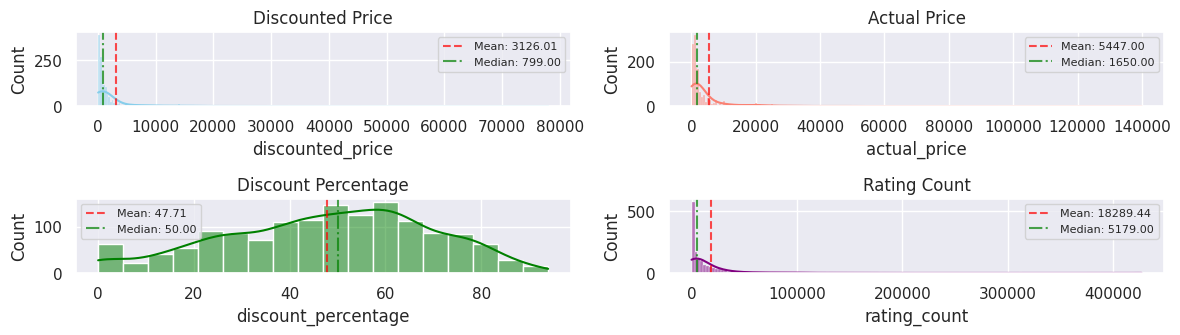

In [17]:
print("\nInitial Distributions")
feature_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']
fig1 = create_distribution_plots(
    df_relevant,
    feature_cols,
    titles=['Discounted Price', 'Actual Price', 'Discount Percentage', 'Rating Count'],
    colors=['skyblue', 'salmon', 'green', 'purple']
)
plt.show()

In [18]:
print("\nApplying Log Transformation")
cols_to_transform = ['discounted_price', 'actual_price', 'rating_count']
df_logged, transform_info = smart_log_transform(df_relevant, cols_to_transform)

print("\nTransformation Summary:")
for col, info in transform_info.items():
    print(f"\n{col}:")
    print(f"  Original range: [{info['original_min']:.2f}, {info['original_max']:.2f}]")
    print(f"  Transformed range: [{info['transformed_min']:.2f}, {info['transformed_max']:.2f}]")


Applying Log Transformation

Transformation Summary:

discounted_price:
  Original range: [39.00, 77990.00]
  Transformed range: [3.69, 11.26]

actual_price:
  Original range: [39.00, 139900.00]
  Transformed range: [3.69, 11.85]

rating_count:
  Original range: [2.00, 426973.00]
  Transformed range: [1.10, 12.96]



Distributions After Log Transformation


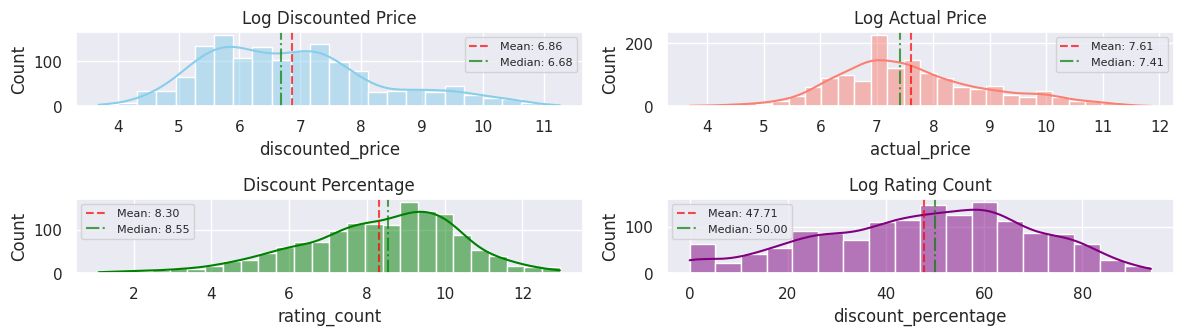

In [19]:
print("\nDistributions After Log Transformation")
fig2 = create_distribution_plots(
    df_logged,
    cols_to_transform + ['discount_percentage'],
    titles=['Log Discounted Price', 'Log Actual Price',
            'Discount Percentage', 'Log Rating Count'],
    colors=['skyblue', 'salmon', 'green', 'purple']
)
plt.show()


Outlier Analysis

Boxplots Before Outlier Handling:


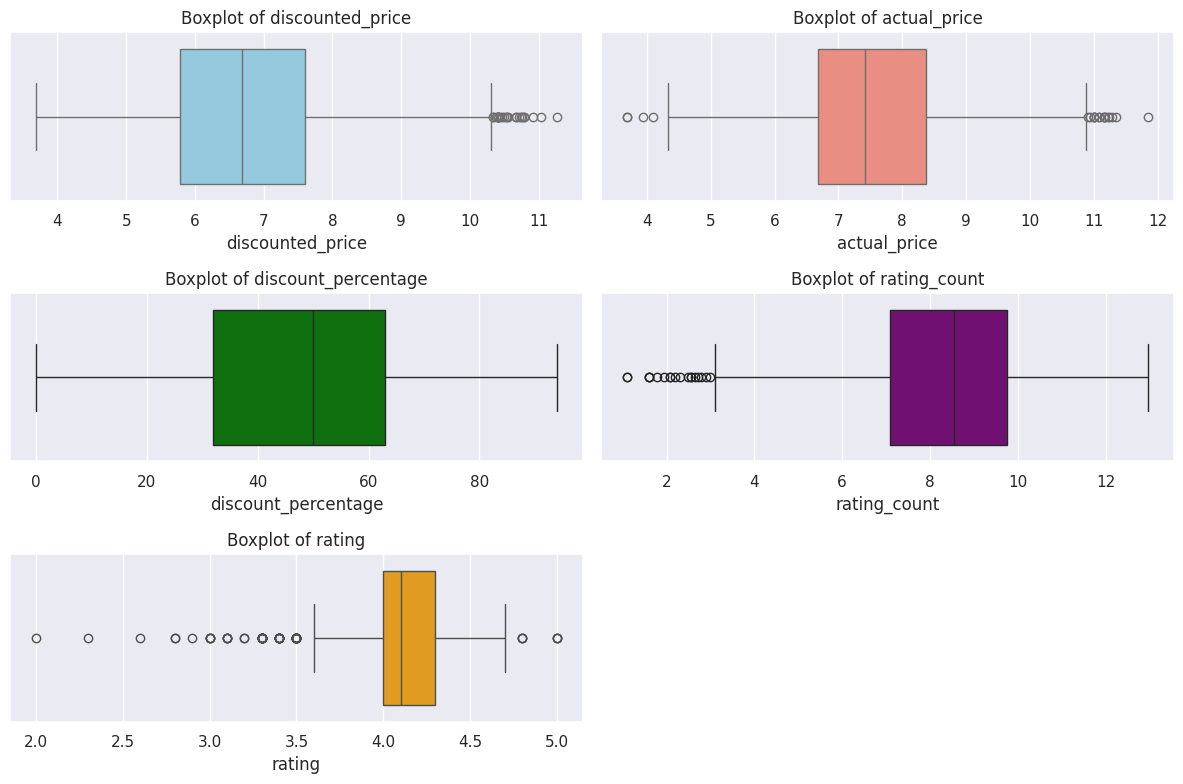


Outlier Statistics:
discounted_price: 25 outliers (1.71%)
actual_price: 21 outliers (1.43%)
discount_percentage: 0 outliers (0.00%)
rating_count: 19 outliers (1.30%)
rating: 74 outliers (5.05%)

Shape before: (1464, 5), after: (1464, 5)

Boxplots After Outlier Handling:


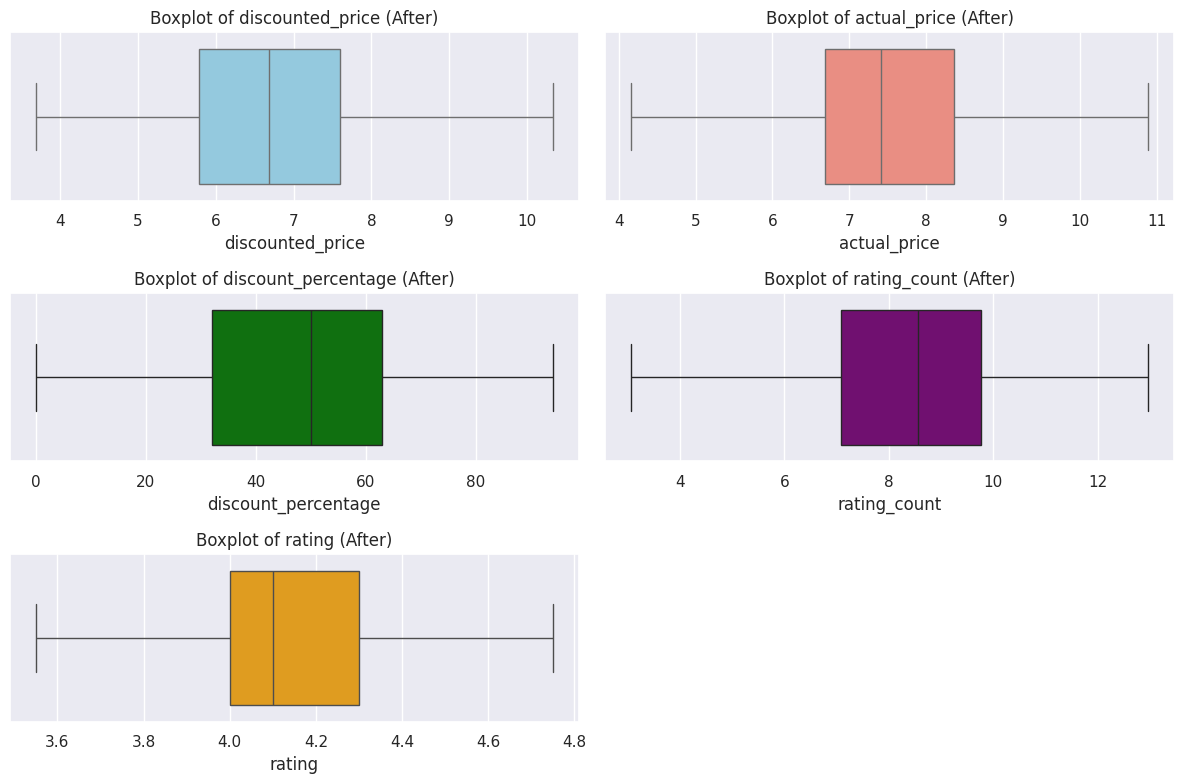

In [20]:
print("\nOutlier Analysis")
print("\nBoxplots Before Outlier Handling:")
fig3 = create_boxplots(
    df_logged,
    df_logged.columns.tolist(),
    titles=[f'Boxplot of {col}' for col in df_logged.columns]
)
plt.show()

# Detect outliers
print("\nOutlier Statistics:")
df_no_outliers, outlier_info = detect_and_handle_outliers(
    df_logged,
    df_logged.columns.tolist(),
    method='cap',
    iqr_multiplier=1.5
)

print("\nBoxplots After Outlier Handling:")
fig4 = create_boxplots(
    df_no_outliers,
    df_no_outliers.columns.tolist(),
    titles=[f'Boxplot of {col} (After)' for col in df_no_outliers.columns]
)
plt.show()

In [21]:
print("\nFeature Engineering")
df_featured = create_smart_features(df_no_outliers)

print("\nData Head After Feature Engineering:")
print(df_featured.head().round(3))

# Check for any issues
print(f"\nNaNs after feature engineering: {df_featured.isna().sum().sum()}")
print(f"Infs after feature engineering: {np.isinf(df_featured).sum().sum()}")



Feature Engineering
Created 5 new features

Data Head After Feature Engineering:
   discounted_price  actual_price  discount_percentage  rating_count  rating  \
0             5.991         7.003                 64.0        10.097     4.2   
1             5.298         5.858                 43.0        10.692     4.0   
2             5.298         7.550                 90.0         8.978     3.9   
3             5.799         6.551                 53.0        11.455     4.2   
4             5.043         5.991                 61.0         9.735     4.2   

   price_ratio  price_diff  discount_effectiveness  weighted_rating  \
0        0.856       1.012                   0.144           10.108   
1        0.904       0.560                   0.096            9.836   
2        0.702       2.251                   0.298            8.972   
3        0.885       0.752                   0.115           10.593   
4        0.842       0.948                   0.158            9.969   

   rating_


Feature Relationships


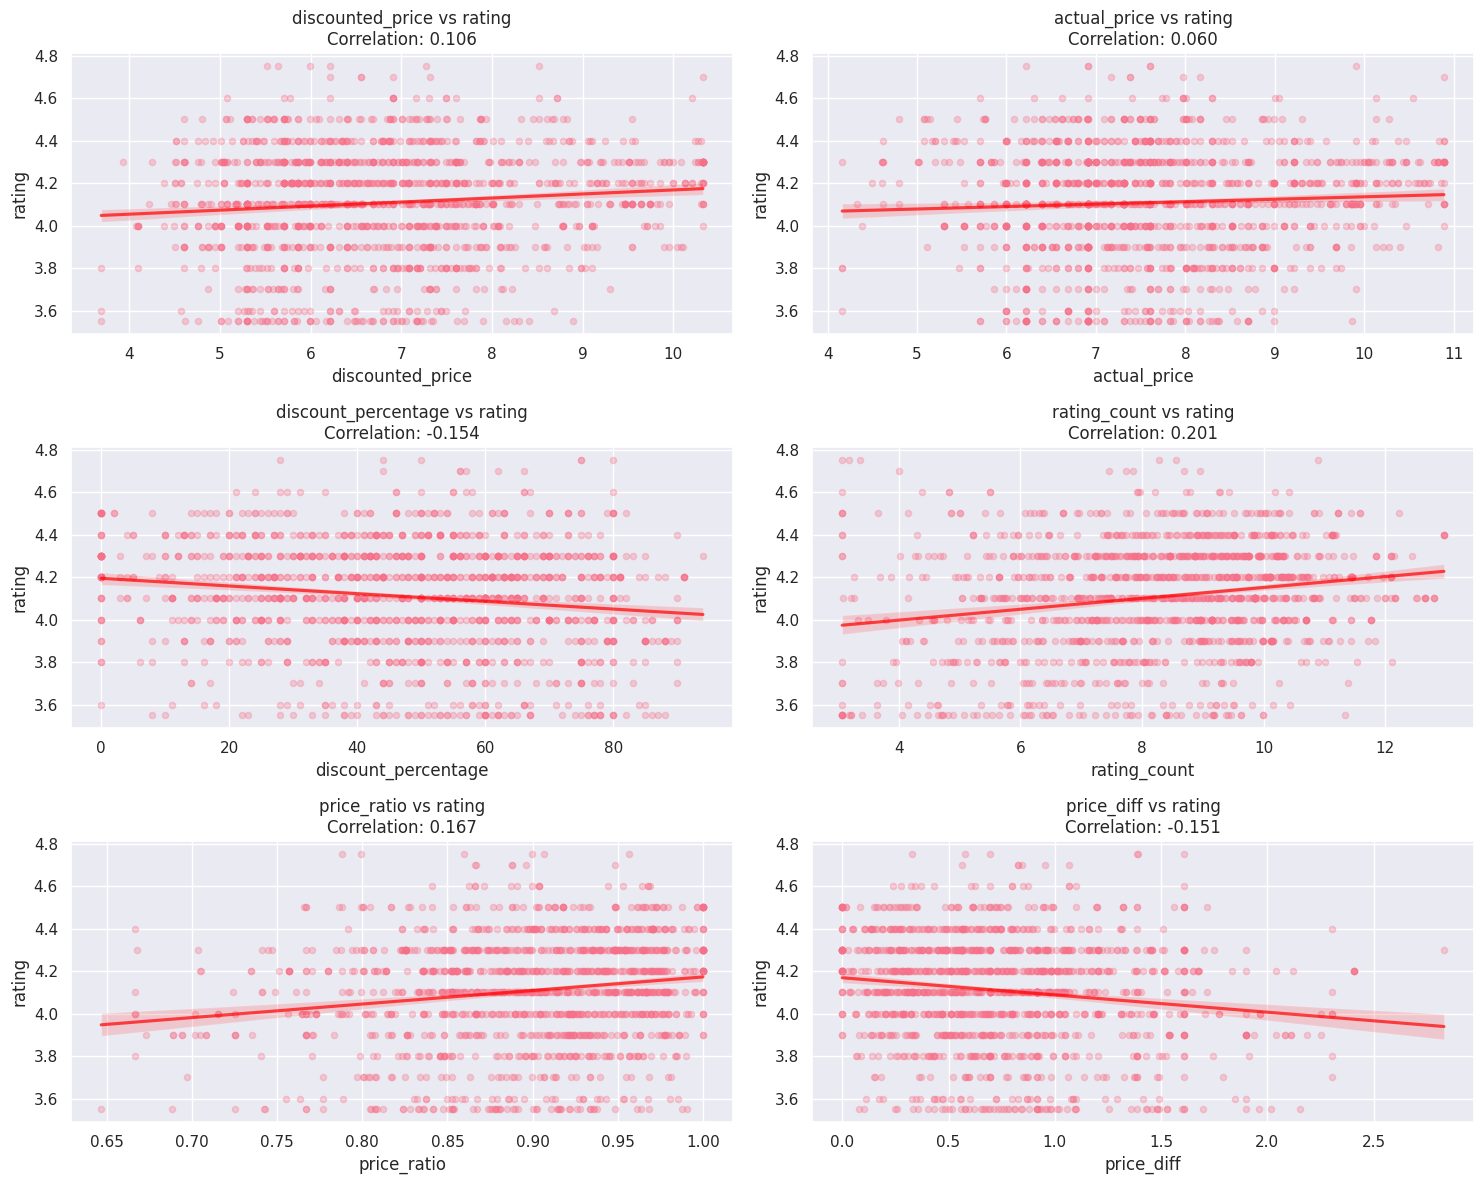

In [22]:
print("\nFeature Relationships")

# Feature vs Target
numeric_cols = df_featured.select_dtypes(include=[np.number]).columns.tolist()
if 'rating' in numeric_cols:
    numeric_cols.remove('rating')

fig5 = visualize_feature_relationships(
    df_featured,
    numeric_cols[:6],  # First 6 features
    target_col='rating',
    figsize=(15, 12)
)
plt.show()


Correlation Analysis:


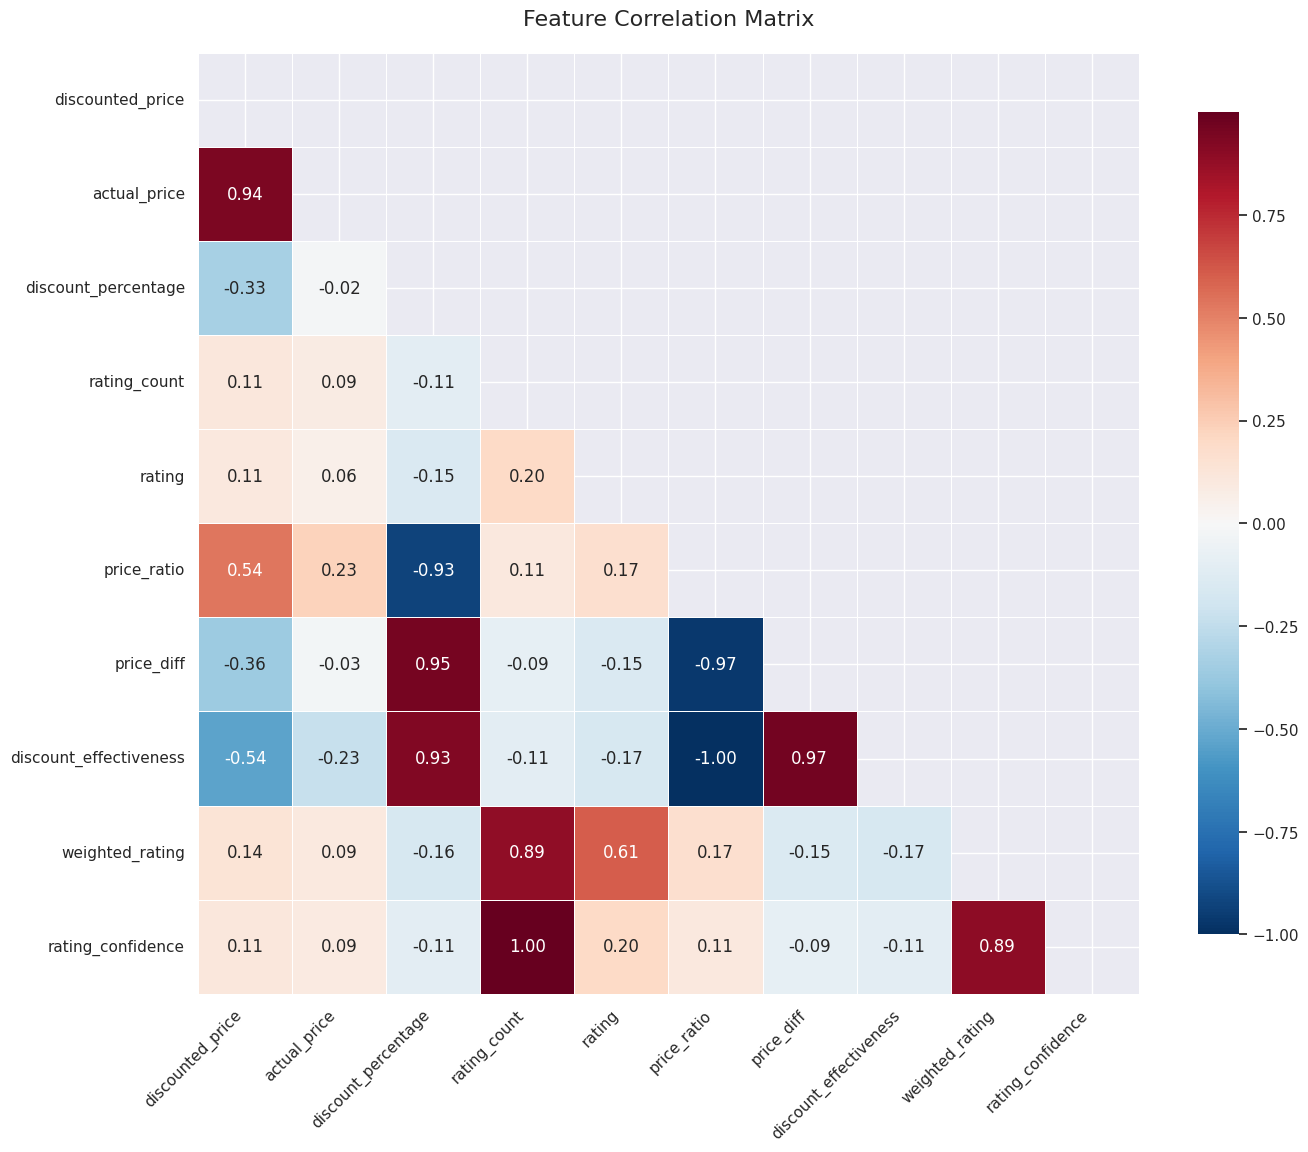

In [23]:
print("\nCorrelation Analysis:")
fig6 = create_correlation_heatmap(
    df_featured,
    title="Feature Correlation Matrix",
    figsize=(14, 12)
)
plt.show()


Creating Rating Categories
Rating categories created: {'Average': 0, 'Excellent': 1, 'Good': 2}

Category distribution:
rating_category
Good         1006
Average       354
Excellent     104
Name: count, dtype: int64


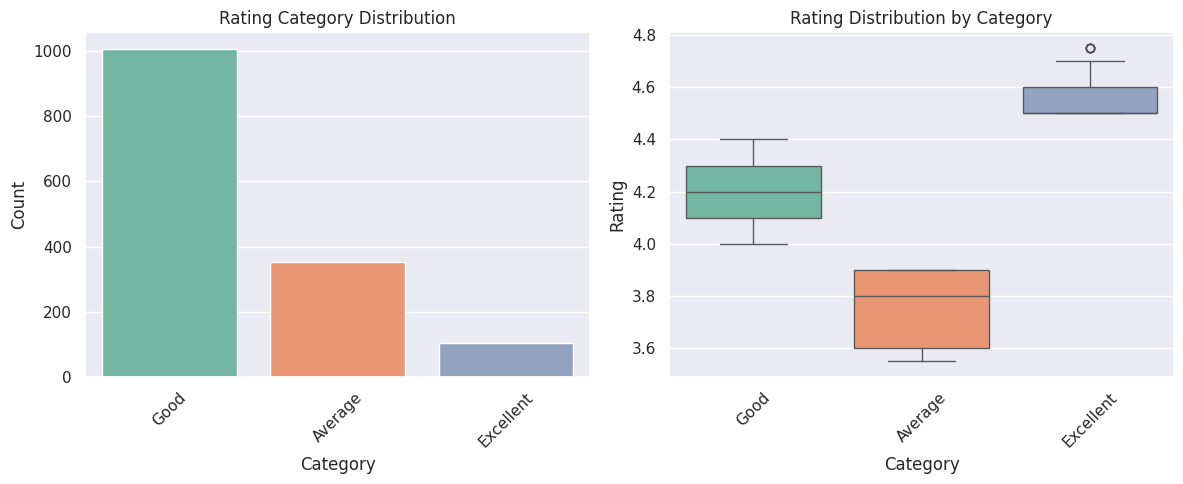

In [24]:
print("\nCreating Rating Categories")
df_categorized, label_map = create_rating_categories(
    df_featured,
    rating_col='rating',
    method='fixed'  # or 'quantile' or 'clustering'
)

# Visualize category distribution
fig7, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='rating_category', data=df_categorized, palette='Set2', ax=ax1)
ax1.set_title('Rating Category Distribution')
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Box plot of rating by category
sns.boxplot(x='rating_category', y='rating', data=df_categorized, palette='Set2', ax=ax2)
ax2.set_title('Rating Distribution by Category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Rating')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Helper Model Functions

In [25]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Comprehensive model evaluation
    """
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n{'='*60}")
    print(f"{model_name.upper()} EVALUATION")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")

    # Weighted metrics
    weighted_avg = report['weighted avg']
    print(f"Weighted Precision: {weighted_avg['precision']:.4f}")
    print(f"Weighted Recall: {weighted_avg['recall']:.4f}")
    print(f"Weighted F1-Score: {weighted_avg['f1-score']:.4f}")

    # ROC-AUC for multiclass
    if y_pred_proba is not None:
        try:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            print(f"ROC-AUC Score: {roc_auc:.4f}")
        except:
            pass

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0], cmap='Blues')
    axes[0].set_title(f'Confusion Matrix - {model_name}')

    # Classification report heatmap
    report_df = pd.DataFrame(report).transpose().iloc[:-3, :3]  # Exclude avg rows
    sns.heatmap(report_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
    axes[1].set_title(f'Classification Report - {model_name}')
    axes[1].set_ylabel('Class')

    plt.tight_layout()
    plt.show()

    return model, accuracy, report

def optimize_model_with_gridsearch(model, param_grid, X_train, y_train,
                                  scoring='accuracy', cv=5, model_name="Model"):
    """
    Optimize model using GridSearchCV with cross-validation
    """
    print(f"\nOptimizing {model_name} with GridSearchCV...")

    # Use StratifiedKFold for imbalanced data
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Score ({scoring}): {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

def plot_feature_importance(model, feature_names, model_name="Model", top_n=10):
    """
    Plot feature importance for tree-based models
    """
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        # Validate feature names length
        n_features = len(importances)
        n_feature_names = len(feature_names)

        if n_features != n_feature_names:
            print(f"[WARNING] Model has {n_features} features but {n_feature_names} feature names provided")

            # Adjust feature names accordingly
            if n_features < n_feature_names:
                print(f"  Using first {n_features} feature names")
                feature_names = feature_names[:n_features]
            else:
                print(f"  Creating generic feature names")
                feature_names = [f'Feature_{i}' for i in range(n_features)]

        indices = np.argsort(importances)[::-1]

        # Adjust top_n if necessary
        top_n = min(top_n, n_features)

        # Plot
        plt.figure(figsize=(10, 6))
        plt.title(f'Feature Importances - {model_name}', fontsize=14)
        bars = plt.bar(range(top_n), importances[indices][:top_n])
        plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
        plt.ylabel('Importance')
        plt.tight_layout()

        # Add value labels on bars
        for bar, importance in zip(bars, importances[indices][:top_n]):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{importance:.3f}', ha='center', va='bottom', fontsize=9)

        plt.show()

        # Print feature importance table
        print(f"\nTop {top_n} Feature Importances for {model_name}:")
        for i in range(top_n):
            print(f"{i+1:2d}. {feature_names[indices[i]]:30s}: {importances[indices[i]]:.4f}")

        return indices
    else:
        print(f"[WARNING]  Model {model_name} does not have feature_importances_ attribute")
        return None

#Model & Training

In [26]:
output_dir = '/content/drive/MyDrive/DataWH/output'
os.makedirs(output_dir, exist_ok=True)

In [27]:
print("\nPreparing Data for Modeling")

if 'df_categorized' in locals():
    df_model = df_categorized.copy()
elif 'df_featured' in locals():
    df_model = df_featured.copy()
else:
    df_model = df_relevant.copy()

print(f"Available columns: {df_model.columns.tolist()}")

# Define target variable
if 'rating_label' in df_model.columns:
    target_col = 'rating_label'
    print("Using 'rating_label' as target variable")
elif 'rating' in df_model.columns:
    # Create rating_label from rating
    def classify_rating(rating):
        if rating >= 4.5:
            return 2  # Good
        elif rating >= 4.0:
            return 1  # Qualified
        else:
            return 0  # Bad

    df_model['rating_label'] = df_model['rating'].apply(classify_rating)
    target_col = 'rating_label'
    print("Created 'rating_label' from 'rating'")
else:
    print("[WARNING] No rating column found!")
    df_model['rating_label'] = np.random.randint(0, 3, size=len(df_model))
    target_col = 'rating_label'

potential_features = [
    'discounted_price', 'actual_price', 'discount_percentage', 'rating_count',
    'price_ratio', 'price_diff', 'discount_effectiveness',
    'weighted_rating', 'rating_confidence'
]

available_features = [col for col in potential_features if col in df_model.columns]

if len(available_features) < 4:
    # Fallback to basic features
    available_features = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']
    print(f"[WARNING]  Using basic features: {available_features}")

print(f"Selected features ({len(available_features)}): {available_features}")
print(f"Target variable: {target_col}")

X = df_model[available_features]
y = df_model[target_col]


Preparing Data for Modeling
Available columns: ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count', 'rating', 'price_ratio', 'price_diff', 'discount_effectiveness', 'weighted_rating', 'rating_confidence', 'rating_category', 'rating_label']
Using 'rating_label' as target variable
Selected features (9): ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count', 'price_ratio', 'price_diff', 'discount_effectiveness', 'weighted_rating', 'rating_confidence']
Target variable: rating_label


In [28]:
print("\nHandling Class Imbalance")
print("Class distribution before balancing:")
class_dist = pd.Series(y).value_counts().sort_index()
for cls, count in class_dist.items():
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE (training only):")
balanced_dist = pd.Series(y_train_balanced).value_counts().sort_index()
for cls, count in balanced_dist.items():
    print(f"  Class {cls}: {count} samples ({count/len(y_train_balanced)*100:.1f}%)")


Handling Class Imbalance
Class distribution before balancing:
  Class 0: 354 samples (24.2%)
  Class 1: 104 samples (7.1%)
  Class 2: 1006 samples (68.7%)

Training set: (1024, 9)
Test set: (440, 9)

Class distribution after SMOTE (training only):
  Class 0: 704 samples (33.3%)
  Class 1: 704 samples (33.3%)
  Class 2: 704 samples (33.3%)


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

scaler_path = os.path.join(output_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"\nScaler saved to: {scaler_path}")


Scaler saved to: /content/drive/MyDrive/DataWH/output/scaler.pkl



RANDOM FOREST CLASSIFIER

Optimizing Random Forest with GridSearchCV...
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (f1_weighted): 0.9556

RANDOM FOREST EVALUATION
Accuracy: 0.9068
Weighted Precision: 0.9189
Weighted Recall: 0.9068
Weighted F1-Score: 0.9108
ROC-AUC Score: 0.9702


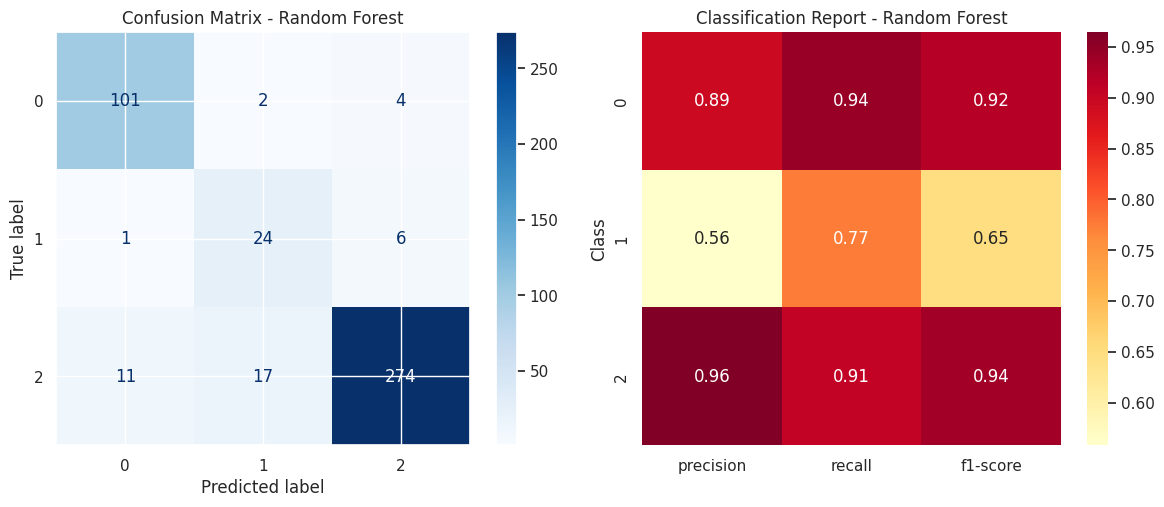

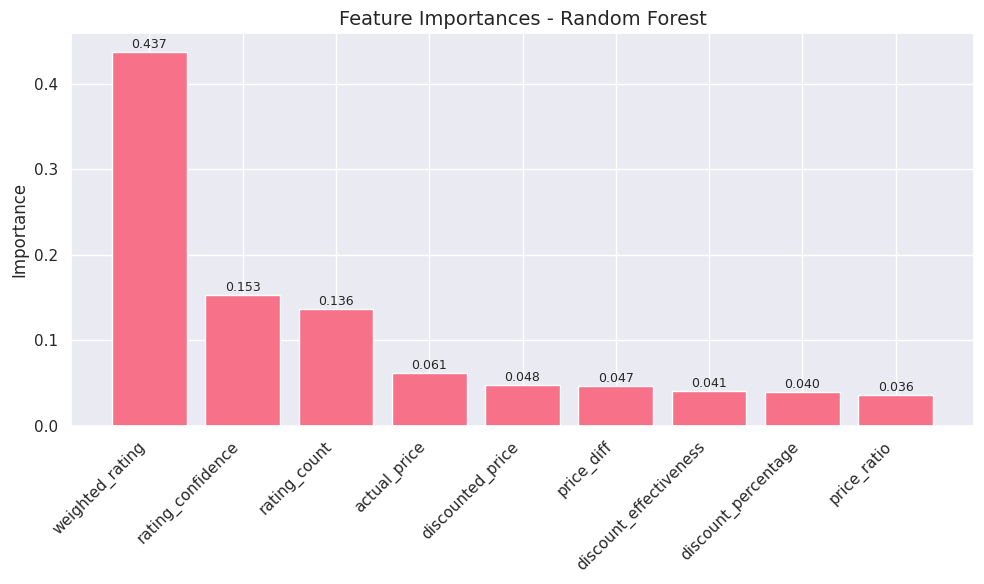


Top 9 Feature Importances for Random Forest:
 1. weighted_rating               : 0.4373
 2. rating_confidence             : 0.1533
 3. rating_count                  : 0.1365
 4. actual_price                  : 0.0613
 5. discounted_price              : 0.0481
 6. price_diff                    : 0.0468
 7. discount_effectiveness        : 0.0408
 8. discount_percentage           : 0.0395
 9. price_ratio                   : 0.0363
Random Forest model saved to: /content/drive/MyDrive/DataWH/output/random_forest_model.pkl


In [30]:
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

# Parameter grid for RandomForest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Train and optimize RandomForest
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
best_rf, rf_best_params, rf_best_score = optimize_model_with_gridsearch(
    rf_model, param_grid_rf, X_train_balanced, y_train_balanced,
    scoring='f1_weighted', cv=5, model_name="Random Forest"
)

# Evaluate on test set
rf_final_model, rf_accuracy, rf_report = evaluate_model(
    best_rf, X_train_balanced, X_test, y_train_balanced, y_test,
    model_name="Random Forest"
)

# Feature importance
rf_feature_indices = plot_feature_importance(rf_final_model, available_features,
                                            model_name="Random Forest", top_n=10)

# Save RandomForest model
rf_model_path = os.path.join(output_dir, 'random_forest_model.pkl')
joblib.dump(rf_final_model, rf_model_path)
print(f"Random Forest model saved to: {rf_model_path}")


XGBOOST CLASSIFIER

Optimizing XGBoost with GridSearchCV...
Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0.2, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score (f1_weighted): 0.9753

XGBOOST EVALUATION
Accuracy: 0.9591
Weighted Precision: 0.9664
Weighted Recall: 0.9591
Weighted F1-Score: 0.9609
ROC-AUC Score: 0.9916


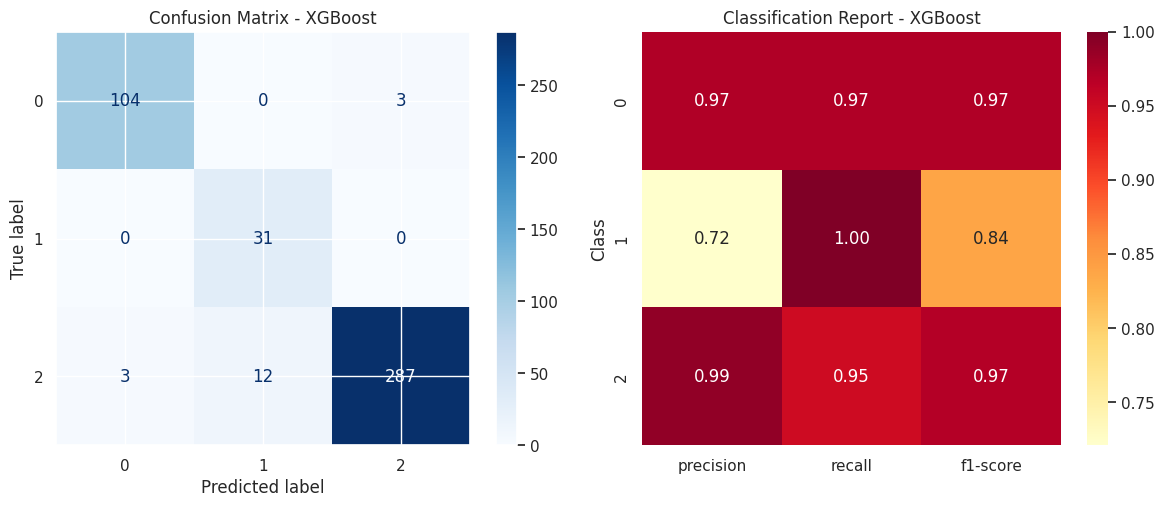

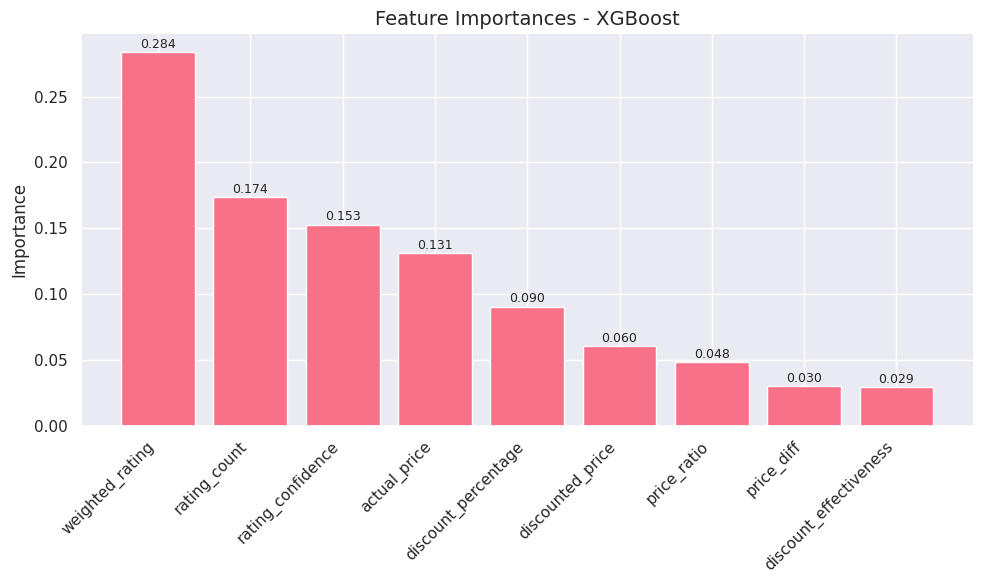


Top 9 Feature Importances for XGBoost:
 1. weighted_rating               : 0.2838
 2. rating_count                  : 0.1737
 3. rating_confidence             : 0.1528
 4. actual_price                  : 0.1311
 5. discount_percentage           : 0.0903
 6. discounted_price              : 0.0604
 7. price_ratio                   : 0.0484
 8. price_diff                    : 0.0300
 9. discount_effectiveness        : 0.0295
XGBoost model saved to: /content/drive/MyDrive/DataWH/output/xgboost_model.pkl


In [31]:
print("\n" + "="*60)
print("XGBOOST CLASSIFIER")
print("="*60)

# Parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Train and optimize XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    objective='multi:softprob'
)

best_xgb, xgb_best_params, xgb_best_score = optimize_model_with_gridsearch(
    xgb_model, param_grid_xgb, X_train_balanced, y_train_balanced,
    scoring='f1_weighted', cv=5, model_name="XGBoost"
)

# Evaluate on test set
xgb_final_model, xgb_accuracy, xgb_report = evaluate_model(
    best_xgb, X_train_balanced, X_test, y_train_balanced, y_test,
    model_name="XGBoost"
)

# Feature importance
xgb_feature_indices = plot_feature_importance(xgb_final_model, available_features,
                                             model_name="XGBoost", top_n=10)

# Save XGBoost model
xgb_model_path = os.path.join(output_dir, 'xgboost_model.pkl')
joblib.dump(xgb_final_model, xgb_model_path)
print(f"XGBoost model saved to: {xgb_model_path}")


K-NEAREST NEIGHBORS CLASSIFIER

Optimizing KNN with GridSearchCV...
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Score (f1_weighted): 0.8916

KNN EVALUATION
Accuracy: 0.8045
Weighted Precision: 0.8337
Weighted Recall: 0.8045
Weighted F1-Score: 0.8139
ROC-AUC Score: 0.8721


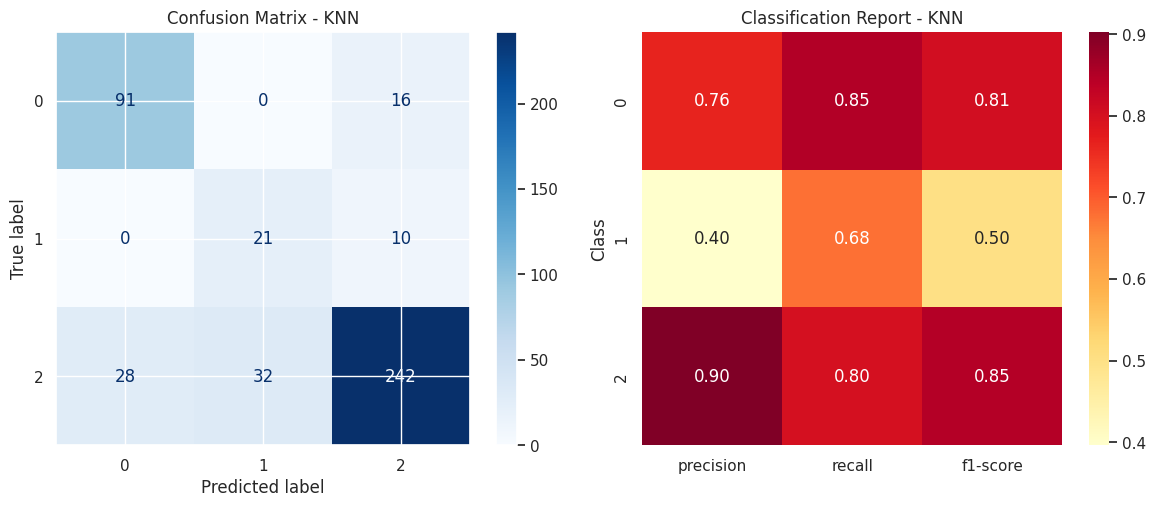

KNN model saved to: /content/drive/MyDrive/DataWH/output/knn_model.pkl


In [32]:
print("\n" + "="*60)
print("K-NEAREST NEIGHBORS CLASSIFIER")
print("="*60)

# Parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Train and optimize KNN (using scaled data)
knn_model = KNeighborsClassifier()
best_knn, knn_best_params, knn_best_score = optimize_model_with_gridsearch(
    knn_model, param_grid_knn, X_train_scaled, y_train_balanced,
    scoring='f1_weighted', cv=5, model_name="KNN"
)

# Evaluate on test set (with scaled data)
knn_final_model, knn_accuracy, knn_report = evaluate_model(
    best_knn, X_train_scaled, X_test_scaled, y_train_balanced, y_test,
    model_name="KNN"
)

# Save KNN model
knn_model_path = os.path.join(output_dir, 'knn_model.pkl')
joblib.dump(knn_final_model, knn_model_path)
print(f"KNN model saved to: {knn_model_path}")


MODEL COMPARISON SUMMARY

Model Performance Comparison:
        Model  Accuracy  Best CV Score                                                                                                           Parameters
Random Forest  0.906818       0.955570        {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
      XGBoost  0.959091       0.975257 {'colsample_bytree': 1.0, 'gamma': 0.2, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
          KNN  0.804545       0.891556                                                     {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


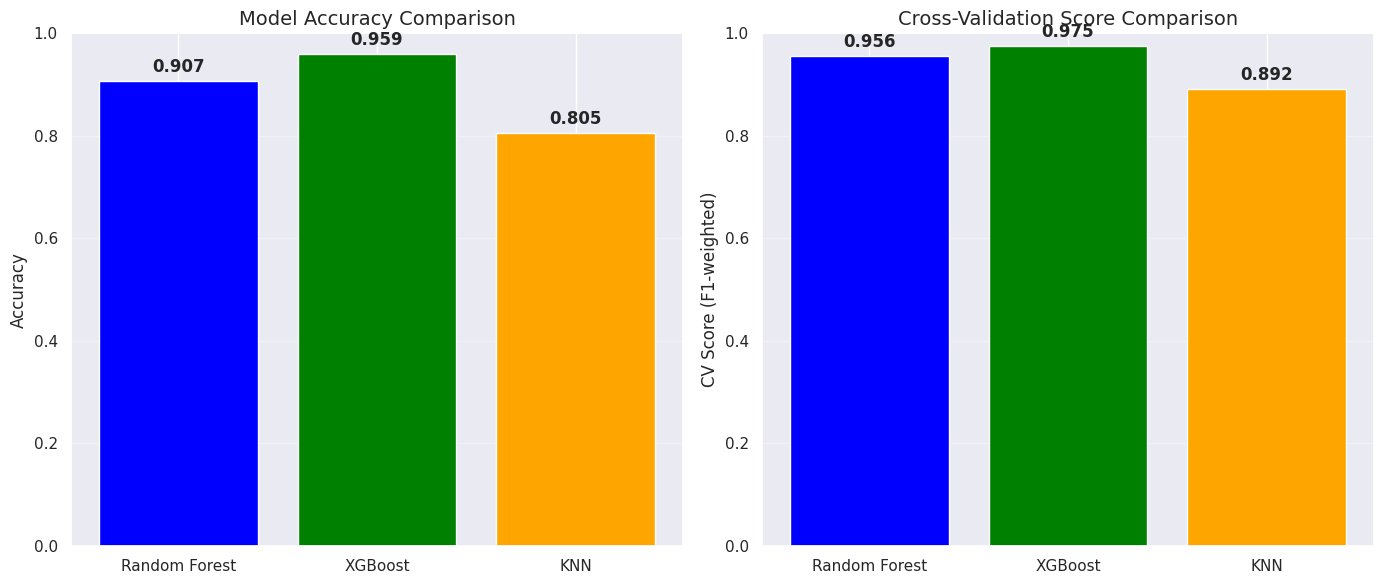


BEST MODEL: XGBoost
Accuracy: 0.9591
Best model (XGBoost) saved to: /content/drive/MyDrive/DataWH/output/best_model.pkl


In [33]:
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'KNN'],
    'Accuracy': [rf_accuracy, xgb_accuracy, knn_accuracy],
    'Best CV Score': [rf_best_score, xgb_best_score, knn_best_score],
    'Parameters': [rf_best_params, xgb_best_params, knn_best_params]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['blue', 'green', 'orange'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# CV Score comparison
axes[1].bar(comparison_df['Model'], comparison_df['Best CV Score'], color=['blue', 'green', 'orange'])
axes[1].set_title('Cross-Validation Score Comparison', fontsize=14)
axes[1].set_ylabel('CV Score (F1-weighted)')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Best CV Score']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Select best model
best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.4f}")

# Load best model based on name
if best_model_name == 'Random Forest':
    best_model = rf_final_model
elif best_model_name == 'XGBoost':
    best_model = xgb_final_model
else:
    best_model = knn_final_model

# Save best model
best_model_path = os.path.join(output_dir, 'best_model.pkl')
joblib.dump(best_model, best_model_path)
print(f"Best model ({best_model_name}) saved to: {best_model_path}")


PRINCIPAL COMPONENT ANALYSIS (PCA)
Explained variance ratio: [0.481112   0.28219505]
Cumulative explained variance: [0.481112   0.76330705]
Total variance explained: 76.33%


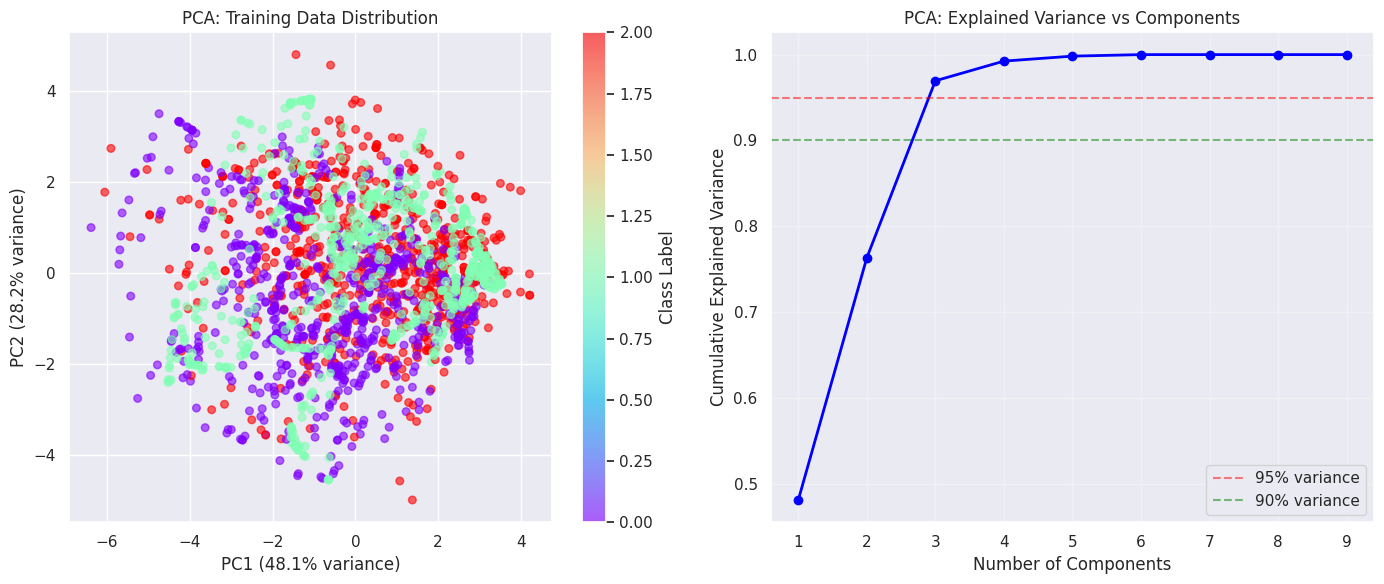


PCA Components Analysis:
Components for 90% variance: 3
Components for 95% variance: 3
Total features: 9


In [34]:
print("\n" + "="*60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*60)

# Use scaled data for PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_)}")
print(f"Total variance explained: {np.sum(pca.explained_variance_ratio_):.2%}")

# PCA visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_balanced,
                         cmap='rainbow', alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA: Training Data Distribution')
plt.colorbar(scatter, ax=axes[0], label='Class Label')

# Explained variance plot
components = range(1, min(10, len(available_features)) + 1)
pca_full = PCA().fit(X_train_scaled)
explained_variance = np.cumsum(pca_full.explained_variance_ratio_[:len(components)])

axes[1].plot(components, explained_variance, 'o-', linewidth=2, color='blue')
axes[1].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% variance')
axes[1].axhline(y=0.90, color='g', linestyle='--', alpha=0.5, label='90% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Explained Variance vs Components')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Check how many components needed for 95% variance
n_components_95 = np.where(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95)[0][0] + 1
n_components_90 = np.where(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90)[0][0] + 1

print(f"\nPCA Components Analysis:")
print(f"Components for 90% variance: {n_components_90}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Total features: {len(available_features)}")

In [35]:
print("\n" + "="*60)
print("FINAL SUMMARY AND SAVING RESULTS")
print("="*60)

# Save comparison results
comparison_path = os.path.join(output_dir, 'model_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"Model comparison saved to: {comparison_path}")

# Save predictions for analysis
predictions_data = {
    'y_true': y_test.values,
    'y_pred_rf': rf_final_model.predict(X_test),
    'y_pred_xgb': xgb_final_model.predict(X_test),
    'y_pred_knn': knn_final_model.predict(X_test_scaled)
}

predictions_df = pd.DataFrame(predictions_data)
predictions_path = os.path.join(output_dir, 'model_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"Model predictions saved to: {predictions_path}")

# Create final report
report_content = f"""
MODEL TRAINING REPORT
=====================
Date: {pd.Timestamp.now()}

DATA SUMMARY
------------
- Original samples: {len(df)}
- Processed samples: {len(df_model)}
- Features used: {len(available_features)}
- Target classes: {len(np.unique(y))}
- Class distribution: {dict(class_dist)}

MODEL PERFORMANCE
-----------------
{comparison_df.to_string(index=False)}

BEST MODEL
----------
- Model: {best_model_name}
- Accuracy: {best_model_accuracy:.4f}
- File: best_model.pkl

PCA ANALYSIS
------------
- Total variance explained (2 components): {np.sum(pca.explained_variance_ratio_):.2%}
- Components for 90% variance: {n_components_90}
- Components for 95% variance: {n_components_95}

FILES SAVED
-----------
1. amazon_processed.csv - Processed data
2. random_forest_model.pkl - Random Forest model
3. xgboost_model.pkl - XGBoost model
4. knn_model.pkl - KNN model
5. best_model.pkl - Best performing model
6. scaler.pkl - StandardScaler object
7. model_comparison.csv - Model comparison results
8. model_predictions.csv - Prediction results
9. processing_metadata.json - Processing metadata
"""

report_path = os.path.join(output_dir, 'model_training_report.txt')
with open(report_path, 'w') as f:
    f.write(report_content)

print(f"Training report saved to: {report_path}")
print("\n" + "="*60)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*60)


FINAL SUMMARY AND SAVING RESULTS
Model comparison saved to: /content/drive/MyDrive/DataWH/output/model_comparison.csv
Model predictions saved to: /content/drive/MyDrive/DataWH/output/model_predictions.csv
Training report saved to: /content/drive/MyDrive/DataWH/output/model_training_report.txt

MODEL TRAINING COMPLETED SUCCESSFULLY!
